# Chronos-2 Quality Net — Results, prediction_length=4, context_length=168 (2026-08-18)

`train/finetune_chronos2.py --prediction-length 4 --context-length 168`, `eval/backtest.py
--context-length 168`로 실행한 결과입니다. prediction_length=4는 `results_context512.ipynb`에서
1보다 낫다고 확인되어 이후 실험의 기본값으로 고정했고, context_length는 512, 128, 73에 이어 이번엔
**168**(약 1주일치 이력)로 스윕 지점을 하나 더 채웠습니다.

이전 실험들과 마찬가지로 **zero-shot도 새로 평가했습니다** — context_length는 파인튜닝 여부와 무관하게
추론 시 모델 입력 길이 자체를 바꾸는 값이라 재사용할 수 없습니다.

이 노트북은 GPU를 다시 쓰지 않습니다 — `eval/backtest_*_predlen4_ctx168_*.csv` 결과 파일만 읽습니다.

비교 대상 4가지:
- **Naive baseline**: 직전 실측값을 그대로 예측값으로 사용
- **Zero-shot**: `amazon/chronos-2` 사전학습 가중치, 파인튜닝 없음, `--context-length 168`로 평가
- **LoRA**: `--prediction-length 4 --context-length 168`로 학습 (`checkpoints/{target}_predlen4_ctx168/final`)
- **Full fine-tuning**: `--prediction-length 4 --context-length 168`, `learning_rate=1e-6` (`checkpoints/{target}_full_predlen4_ctx168/final`)

In [1]:
import sys
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows 한글 폰트
matplotlib.rcParams['axes.unicode_minus'] = False

ROOT = Path.cwd()
if not (ROOT / "config.py").exists():
    raise RuntimeError(
        f"config.py를 {ROOT} 에서 찾지 못했습니다. Jupyter를 chronos_quality_net 폴더에서 실행하거나, "
        "이 노트북을 그 폴더로 옮겨서 다시 여세요."
    )
sys.path.insert(0, str(ROOT))
import config as cfg

TARGETS = cfg.TARGET_COLS  # ["blaine", "residue"]
print("targets:", TARGETS)
print("spec ranges:", cfg.SPEC_RANGES)

METHOD_TAGS = {
    "zero-shot": "predlen4_ctx168_zeroshot",
    "LoRA": "predlen4_ctx168_lora",
    "Full fine-tuning": "predlen4_ctx168_full",
}
METHODS = list(METHOD_TAGS.keys())

targets: ['blaine', 'residue']
spec ranges: {'blaine': (3700.0, 3900.0), 'residue': (7.0, 9.0)}


## 1. 결과 파일 불러오기

In [2]:
EVAL_DIR = ROOT / "eval"

results = {}
for target in TARGETS:
    results[target] = {}
    for method, tag in METHOD_TAGS.items():
        p = EVAL_DIR / f"backtest_{target}_{tag}.csv"
        if p.exists():
            results[target][method] = pd.read_csv(p, parse_dates=["timestamp"])
        else:
            print(f"[missing] {p}")

for target in TARGETS:
    for method in METHODS:
        df = results[target].get(method)
        print(target, method, "->", None if df is None else f"{len(df)} rows")

blaine zero-shot -> 1007 rows
blaine LoRA -> 1007 rows
blaine Full fine-tuning -> 1007 rows
residue zero-shot -> 979 rows
residue LoRA -> 979 rows
residue Full fine-tuning -> 979 rows


## 2. 요약 지표 (MAE / RMSE / R² / Spec 정확도 / 80% 구간 커버리지)

In [3]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, confusion_matrix


def categorize(values, lo, hi):
    return np.where((values >= lo) & (values <= hi), "IN_SPEC", "OUT_OF_SPEC")


def compute_metrics(df: pd.DataFrame, target: str, pred_col: str) -> dict:
    lo, hi = cfg.SPEC_RANGES[target]
    mae = mean_absolute_error(df["actual"], df[pred_col])
    rmse = np.sqrt(mean_squared_error(df["actual"], df[pred_col]))
    r2 = r2_score(df["actual"], df[pred_col])
    actual_cls = categorize(df["actual"].to_numpy(), lo, hi)
    pred_cls = categorize(df[pred_col].to_numpy(), lo, hi)
    spec_accuracy = float((actual_cls == pred_cls).mean())
    row = {"MAE": mae, "RMSE": rmse, "R2": r2, "spec_accuracy": spec_accuracy, "n": len(df)}
    if pred_col == "pred" and "pred_q10" in df.columns and "pred_q90" in df.columns:
        row["interval_coverage"] = float(
            ((df["actual"] >= df["pred_q10"]) & (df["actual"] <= df["pred_q90"])).mean()
        )
    else:
        row["interval_coverage"] = np.nan
    return row


rows = []
for target in TARGETS:
    first_df = next((df for df in results[target].values() if df is not None), None)
    if first_df is not None:
        rows.append({"target": target, "method": "naive", **compute_metrics(first_df, target, "naive_pred")})
    for method in METHODS:
        df = results[target].get(method)
        if df is not None:
            rows.append({"target": target, "method": method, **compute_metrics(df, target, "pred")})

summary = pd.DataFrame(rows).set_index(["target", "method"])
summary.round(4)

MAE     RMSE      R2  spec_accuracy     n  \
target  method                                                            
blaine  naive             63.2075  92.9357  0.3908         0.7259  1007   
        zero-shot         67.4206  93.4355  0.3843         0.6862  1007   
        LoRA              67.3528  93.3233  0.3857         0.6882  1007   
        Full fine-tuning  65.8892  90.9673  0.4164         0.7140  1007   
residue naive              0.4150   0.6203  0.8091         0.8131   979   
        zero-shot          0.4442   0.6234  0.8072         0.7835   979   
        LoRA               0.4436   0.6224  0.8078         0.7835   979   
        Full fine-tuning   0.4386   0.6118  0.8144         0.7855   979   

                          interval_coverage  
target  method                               
blaine  naive                           NaN  
        zero-shot                    0.4449  
        LoRA                         0.4459  
        Full fine-tuning             0.4806  
residue naive                           NaN  
        zero-shot                    0.4249  
        LoRA                         0.4311  
        Full fine-tuning             0.4597

## 3. 방식별 비교 막대그래프 (MAE, RMSE, Spec 정확도)

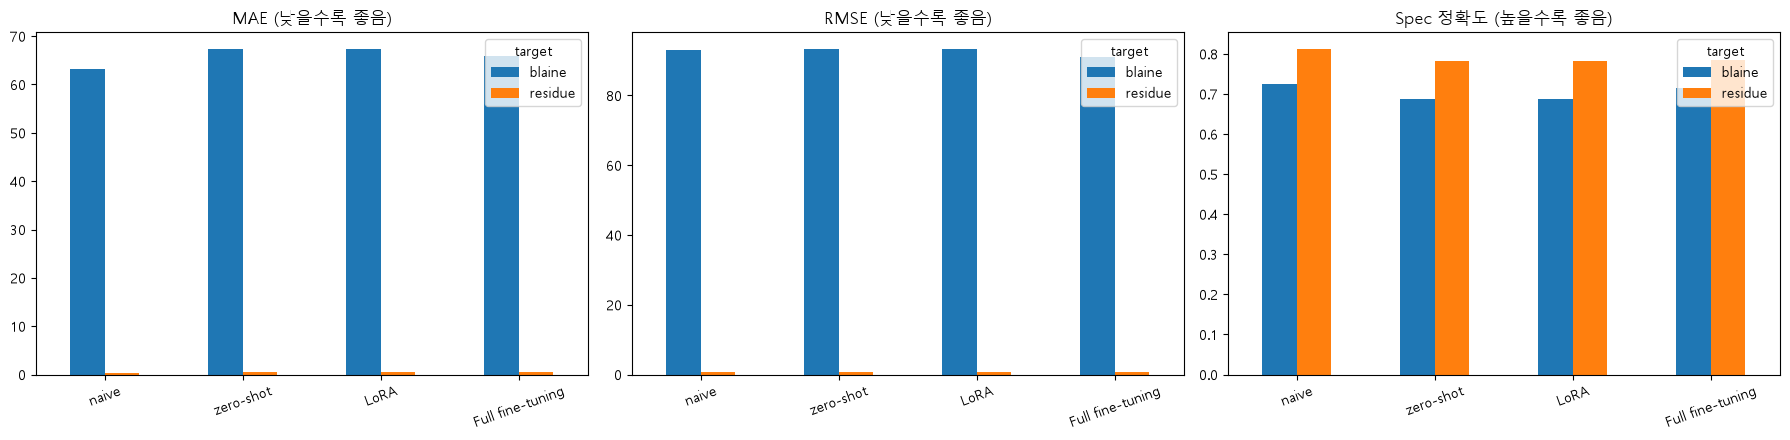

In [4]:
method_order = ["naive"] + METHODS
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

metrics = ["MAE", "RMSE", "spec_accuracy"]
titles = ["MAE (낮을수록 좋음)", "RMSE (낮을수록 좋음)", "Spec 정확도 (높을수록 좋음)"]
for ax, metric, title in zip(axes, metrics, titles):
    plot_df = summary[metric].unstack("target").reindex(method_order)
    plot_df.plot(kind="bar", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.legend(title="target")
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

## 4. 실제값 vs 예측값 산점도 (naive / zero-shot / LoRA / full)

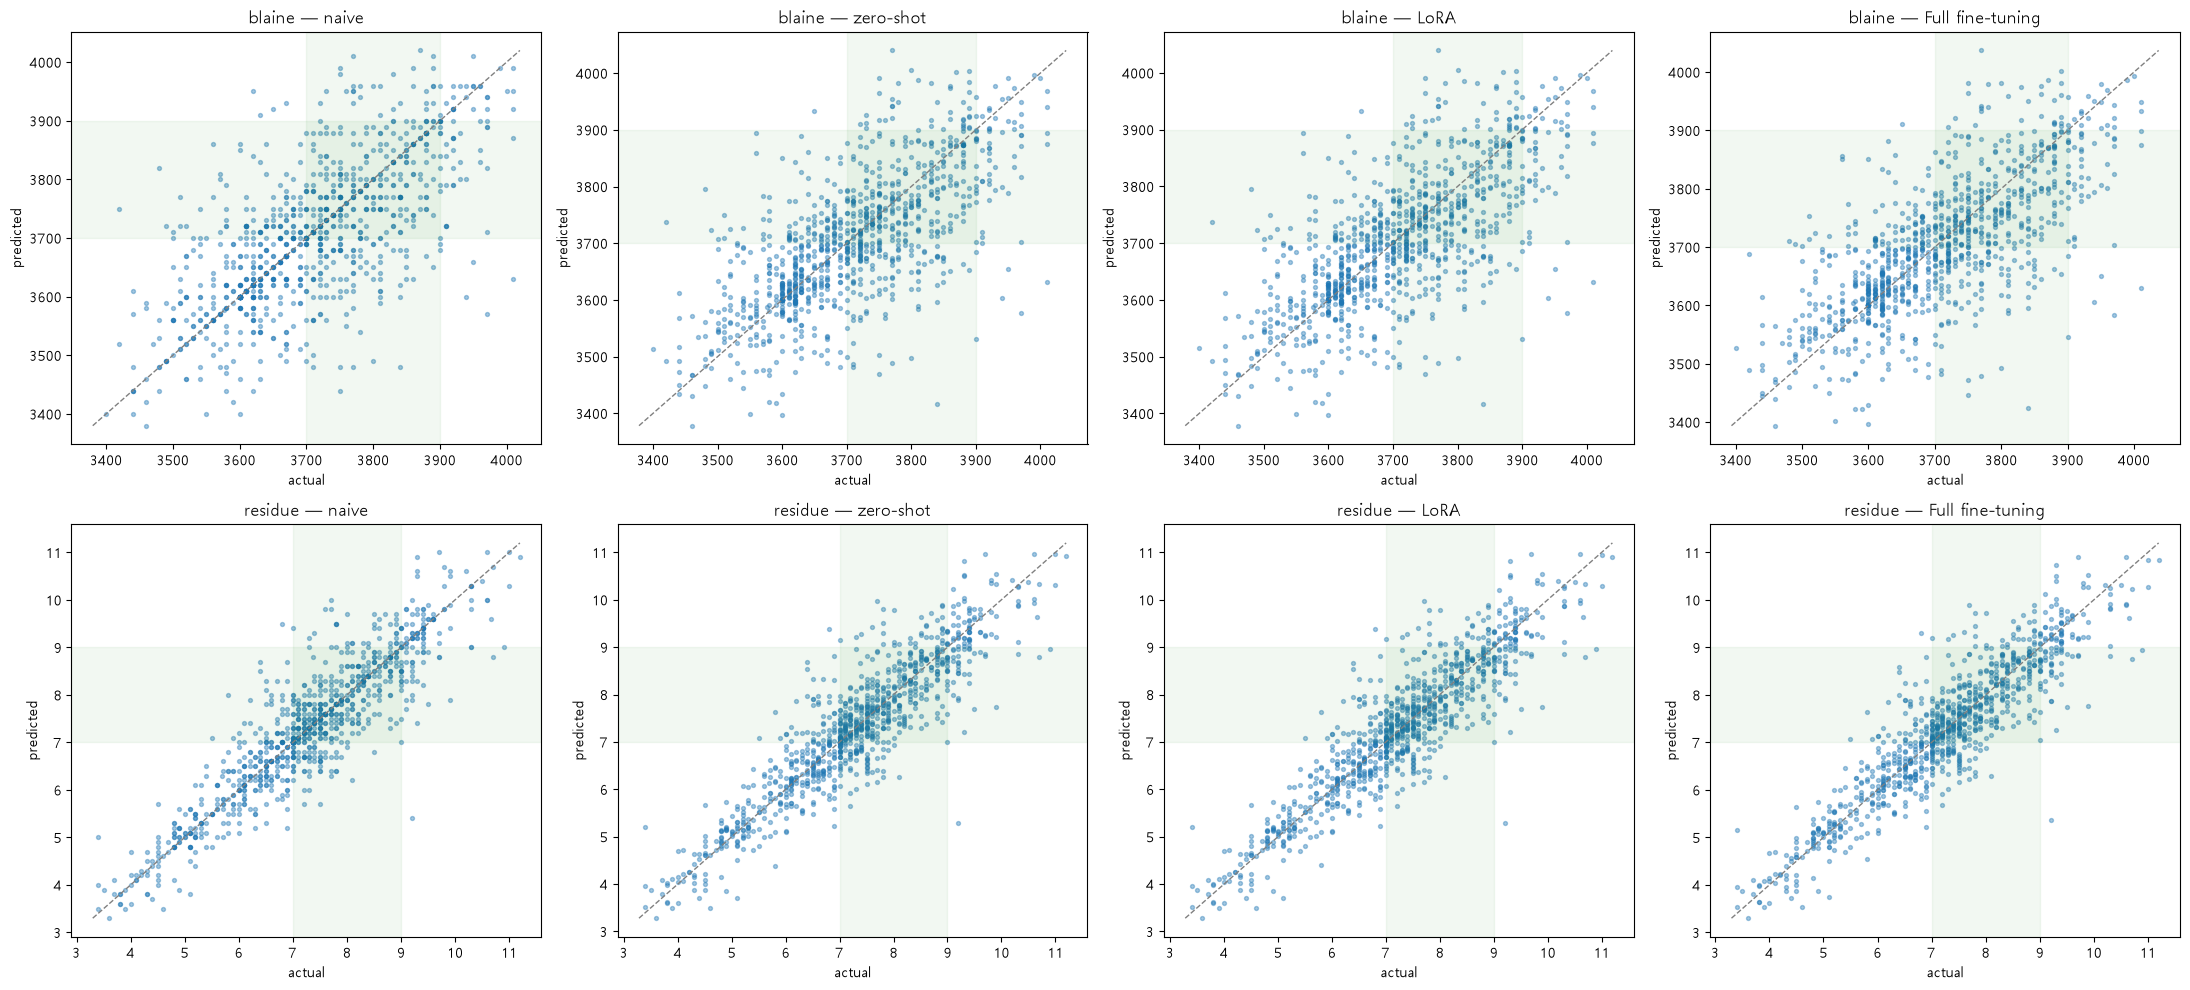

In [5]:
fig, axes = plt.subplots(len(TARGETS), 1 + len(METHODS), figsize=(5.5 * (1 + len(METHODS)), 5 * len(TARGETS)))
if len(TARGETS) == 1:
    axes = axes[None, :]

for row, target in enumerate(TARGETS):
    lo, hi = cfg.SPEC_RANGES[target]
    first_df = next((df for df in results[target].values() if df is not None), None)
    cols = [("naive", "naive_pred", first_df)] + [(m, "pred", results[target].get(m)) for m in METHODS]
    for col_idx, (label, pred_col, df) in enumerate(cols):
        ax = axes[row, col_idx]
        if df is None:
            ax.set_visible(False)
            continue
        ax.scatter(df["actual"], df[pred_col], s=8, alpha=0.4)
        lims = [min(df["actual"].min(), df[pred_col].min()), max(df["actual"].max(), df[pred_col].max())]
        ax.plot(lims, lims, color="gray", linestyle="--", linewidth=1)
        ax.axvspan(lo, hi, color="green", alpha=0.05)
        ax.axhspan(lo, hi, color="green", alpha=0.05)
        ax.set_title(f"{target} — {label}")
        ax.set_xlabel("actual")
        ax.set_ylabel("predicted")

plt.tight_layout()
plt.show()

## 5. 시계열: 실제값 vs 예측 + 80% 예측구간 (full fine-tuning 모델, 호기별)

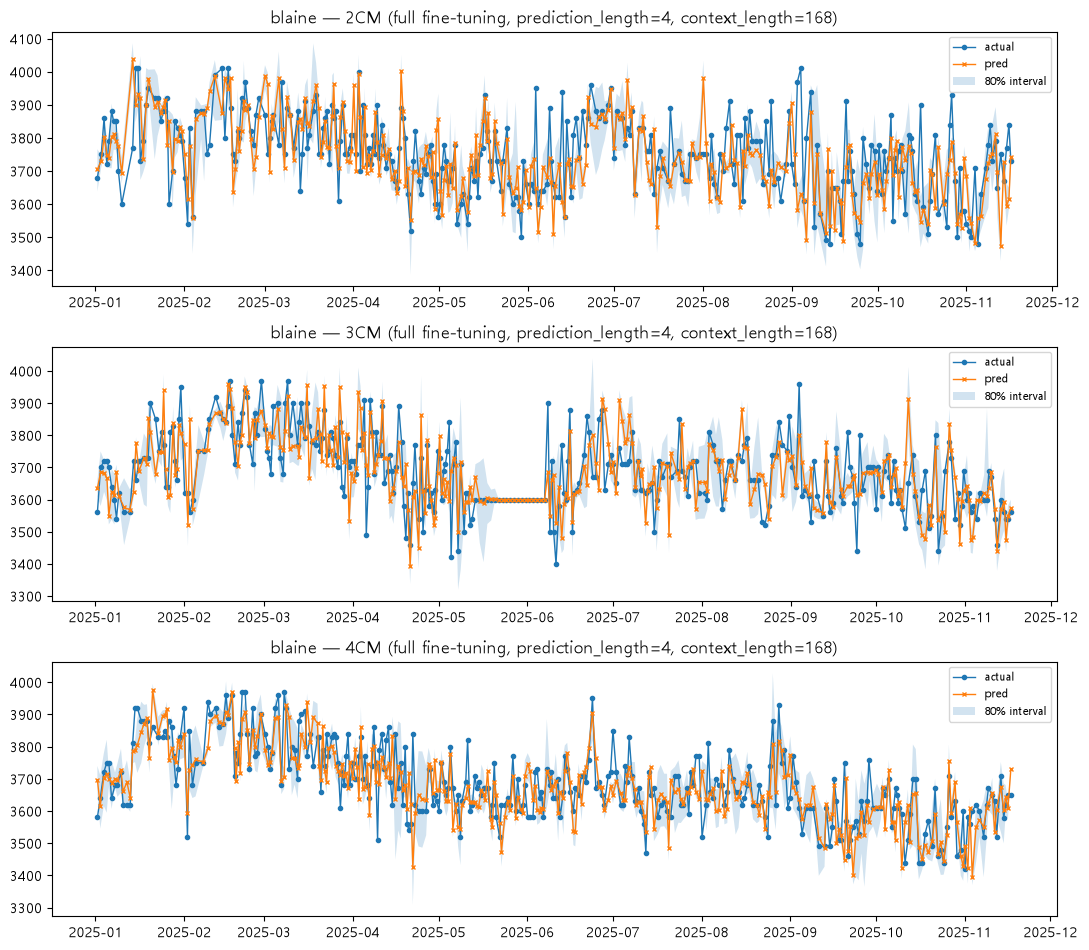

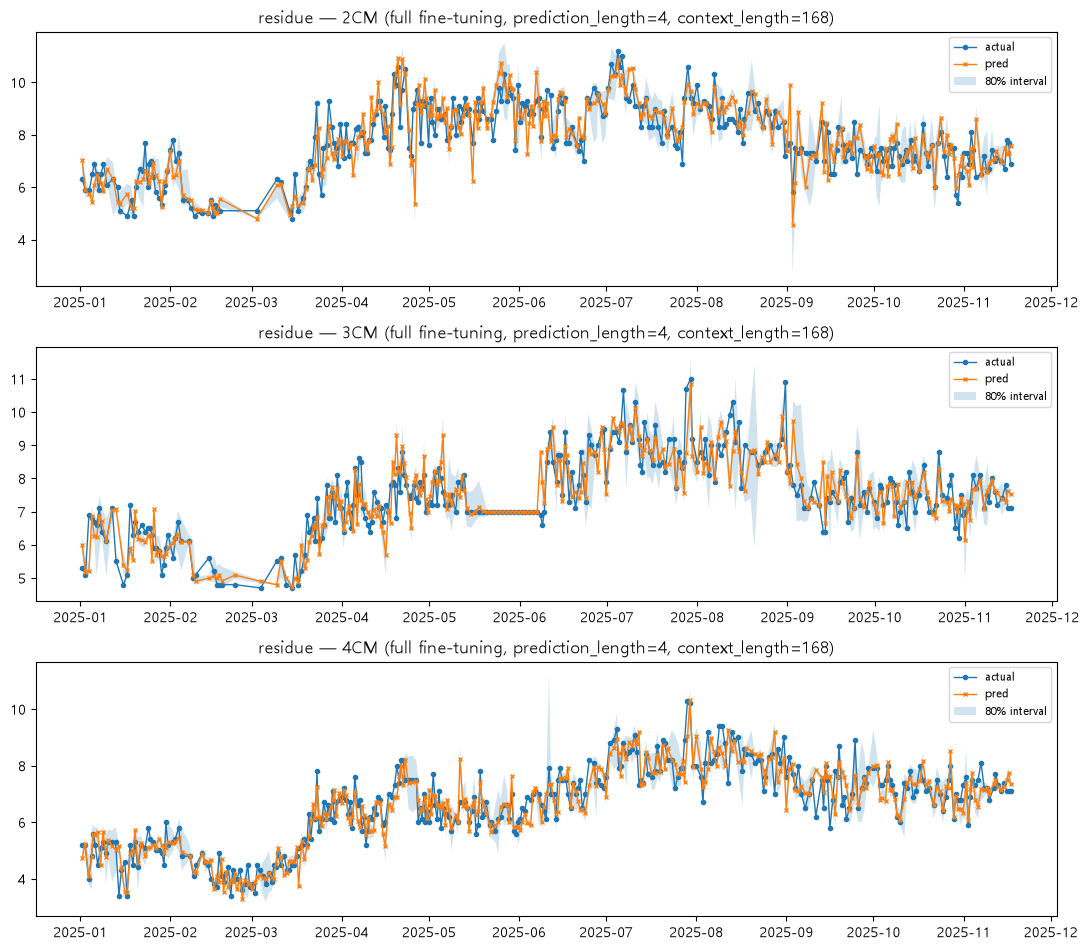

In [6]:
for target in TARGETS:
    df = results[target].get("Full fine-tuning")
    if df is None:
        continue
    item_ids = sorted(df["item_id"].unique())
    fig, axes = plt.subplots(len(item_ids), 1, figsize=(11, 3.2 * len(item_ids)), sharex=False)
    if len(item_ids) == 1:
        axes = [axes]
    for ax, item_id in zip(axes, item_ids):
        g = df[df["item_id"] == item_id].sort_values("timestamp")
        ax.plot(g["timestamp"], g["actual"], label="actual", marker="o", markersize=3, linewidth=1)
        ax.plot(g["timestamp"], g["pred"], label="pred", marker="x", markersize=3, linewidth=1)
        ax.fill_between(g["timestamp"], g["pred_q10"], g["pred_q90"], alpha=0.2, label="80% interval")
        ax.set_title(f"{target} — {item_id} (full fine-tuning, prediction_length=4, context_length=168)")
        ax.legend(loc="upper right", fontsize=8)
    plt.tight_layout()
    plt.show()

## 6. Confusion Matrix (Spec-in / Spec-out)

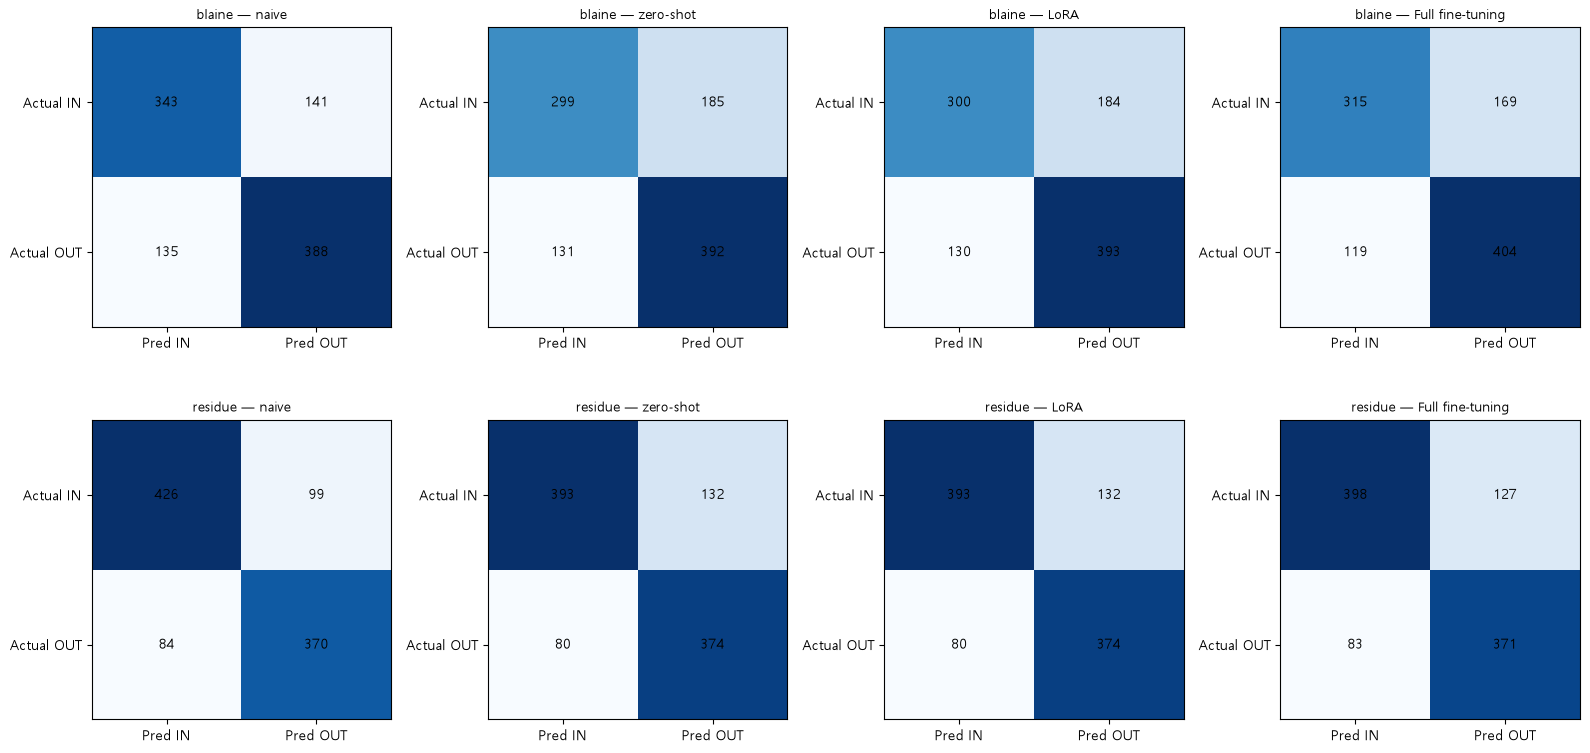

In [7]:
def plot_cm(ax, actual, pred, lo, hi, title):
    actual_cls = categorize(actual, lo, hi)
    pred_cls = categorize(pred, lo, hi)
    cm = confusion_matrix(actual_cls, pred_cls, labels=["IN_SPEC", "OUT_OF_SPEC"])
    ax.imshow(cm, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Pred IN", "Pred OUT"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Actual IN", "Actual OUT"])
    ax.set_title(title, fontsize=9)


fig, axes = plt.subplots(len(TARGETS), 1 + len(METHODS), figsize=(4 * (1 + len(METHODS)), 4 * len(TARGETS)))
if len(TARGETS) == 1:
    axes = axes[None, :]

for row, target in enumerate(TARGETS):
    lo, hi = cfg.SPEC_RANGES[target]
    first_df = next((df for df in results[target].values() if df is not None), None)
    cols = [("naive", "naive_pred", first_df)] + [(m, "pred", results[target].get(m)) for m in METHODS]
    for col_idx, (label, pred_col, df) in enumerate(cols):
        ax = axes[row, col_idx]
        if df is None:
            ax.set_visible(False)
            continue
        plot_cm(ax, df["actual"].to_numpy(), df[pred_col].to_numpy(), lo, hi, f"{target} — {label}")

plt.tight_layout()
plt.show()

## 7. 결론

지금까지 prediction_length=4 기준으로 확보한 context_length 4개 지점(512, 168, 128, 73)을 비교하면
(모두 full fine-tuning 기준 MAE / R², context_length 내림차순):

| context_length | blaine MAE | blaine R² | residue MAE | residue R² |
|---|---|---|---|---|
| 512 (`results_context512.ipynb`) | **64.18** | **0.4550** | **0.4298** | **0.8295** |
| 168 (본 노트북) | 65.89 | 0.4164 | 0.4386 | 0.8144 |
| 73 (`results_context73.ipynb`) | 66.66 | 0.4010 | 0.4371 | 0.8158 |
| 128 (`results_context128.ipynb`) | 68.51 | 0.3635 | 0.4401 | 0.8111 |

- **context_length=512가 여전히 압도적 1위**입니다. 512와 168 사이에 격차가 꽤 있어서(blaine MAE
  64.18→65.89), 512 근처(예: 256, 384) 어딘가에서 성능이 급격히 좋아지는 지점이 있을 가능성이 있습니다.
- **168은 512 다음으로 두 번째로 좋은 지점**입니다(blaine 기준). 그런데 **73보다 context가 두 배 이상
  긴데도 residue는 73(0.4371)이 168(0.4386)보다 살짝 낫습니다** — `results_context73.ipynb`에서 이미
  확인한 "context_length와 성능이 단조적으로 비례하지 않는다"는 관찰이 이번에도 재현됐습니다. blaine은
  반대로 168(65.89)이 73(66.66)보다 나아서, **두 타깃이 서로 다른 지점에서 최적/최악을 보입니다** —
  하나의 "최적 context_length"로 깔끔하게 수렴하지 않고 있습니다.
- 512, 168, 73, 128 네 지점을 순서대로 그려보면(blaine MAE 기준) 512(최고) → 168 → 73 → 128(최저)로,
  단순히 "짧을수록 나쁘다"가 아니라 **128 부근에 국소적으로 나쁜 지점(dip)이 있고 73은 거기서 다시
  약간 회복**하는, 매끄럽지 않은 곡선 형태입니다. 지금 4개 지점만으로는 이 dip의 원인(노이즈인지, 실제
  구조적 패턴인지)을 판단하기 어렵습니다.
- **80% 구간 커버리지**: 168(46~48%)이 73/128(45~51%)과 비슷한 수준이고, 여전히 512(48~51%)에는
  못 미칩니다.
- 종합하면 지금까지 실험한 조합 중 **context_length=512 + prediction_length=4**가 여전히 최고
  성능이고, 그 다음이 168입니다. context_length를 줄이는 방향은 전반적으로 손해이지만, 512 미만
  구간에서의 정확한 형태(단조적인지 dip이 있는지)는 아직 불확실합니다.

prediction_length=4, context_length=512 결과는 `results_context512.ipynb`, context_length=128 결과는
`results_context128.ipynb`, context_length=73 결과는 `results_context73.ipynb`, 기준선
(prediction_length=1, context_length=512)은 `results.ipynb`, context_length=24(prediction_length=1)
결과는 `results_context24.ipynb` 참고.